#Task 0: Preprocessing (Star Ratings to Sentiment Classes)


In [1]:
!pip install datasets transformers evaluate scikit-learn matplotlib --quiet



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate
from sentence_transformers import SentenceTransformer #A library used to transform sentences and text into vector embeddings using pre-trained models like Sentence-BERT.
from sklearn.cluster import KMeans #An algorithm for clustering data into groups (clusters).
import seaborn as sns

In [3]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset and drop rows with missing review text or ratings
df = pd.read_csv("/content/drive/MyDrive/content/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")
df = df.dropna(subset=['reviews.text', 'reviews.rating'])


Mounted at /content/drive


In [4]:
# Function to map star ratings to sentiment classes
def map_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

# Apply sentiment mapping to the dataset
df["sentiment"] = df["reviews.rating"].apply(map_sentiment)

In [5]:
# Separate the data into the three sentiment classes
positive = df[df['sentiment'] == 'Positive']
neutral = df[df['sentiment'] == 'Neutral']
negative = df[df['sentiment'] == 'Negative']

# Get the size of the smallest class for balancing
min_size = min(len(positive), len(neutral), len(negative))

# Downsample each class to the size of the smallest class
positive_down = resample(positive, replace=False, n_samples=min_size, random_state=42)
neutral_down = resample(neutral, replace=False, n_samples=min_size, random_state=42)
negative_down = resample(negative, replace=False, n_samples=min_size, random_state=42)

# Combine and shuffle the balanced dataset
df_balanced = pd.concat([positive_down, neutral_down, negative_down])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Create mappings from sentiment labels to numeric values
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
df_balanced["label"] = df_balanced["sentiment"].map(label2id)


In [6]:
pip install wandb

#Task 1. Classification with pre-trained models.


In [7]:
# Split the data into training and testing sets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_balanced["reviews.text"].tolist(),
    df_balanced["label"].tolist(),
    test_size=0.2,
    random_state=42
)

# Convert the datasets into HuggingFace's Dataset format
train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
test_dataset = Dataset.from_dict({"text": test_texts, "label": test_labels})


In [8]:
import os
# Tokenization function for transformer models
def tokenize_function(example, tokenizer):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)

# Model training function
def train_model(model_name, output_dir):
    print(f"Training model: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    # Tokenize training and test datasets (text to numbers)
    tokenized_train = train_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    tokenized_test = test_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)

    # Load the pre-trained model with 3 output labels
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3, id2label=id2label, label2id=label2id
    )
    # Training configuration
    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        num_train_epochs=5,
        weight_decay=0.01,
        save_total_limit=1,
        logging_dir=f'{output_dir}/logs',
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True
    )
    # Load evaluation metrics
    metric_accuracy = evaluate.load("accuracy")
    metric_f1 = evaluate.load("f1")

    # Metric computation function
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc = metric_accuracy.compute(predictions=predictions, references=labels)
        f1 = metric_f1.compute(predictions=predictions, references=labels, average='weighted')
        return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

    # Disable Weights & Biases logging
    os.environ["WANDB_DISABLED"] = "true"

    # Create the Trainer instance
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    # Train the model
    trainer.train()

    # Save the trained model
    trainer.save_model(output_dir)

    # Evaluate model on test set
    predictions_output = trainer.predict(tokenized_test)
    y_true = predictions_output.label_ids
    y_pred = np.argmax(predictions_output.predictions, axis=1)

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))


    # Display confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

In [11]:
pip install wandb

Training model: bert-base-uncased


Map:   0%|          | 0/2894 [00:00<?, ? examples/s]

Map:   0%|          | 0/724 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-8-8ab4ca2ea504>:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.556208,0.774862,0.777300
2,No log,0.620194,0.783149,0.785553
3,0.424000,0.750139,0.809392,0.809004
4,0.424000,0.856867,0.814917,0.816265
5,0.424000,0.877352,0.823204,0.825490



Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84       233
     Neutral       0.71      0.79      0.75       239
    Positive       0.93      0.84      0.88       252

    accuracy                           0.82       724
   macro avg       0.83      0.82      0.82       724
weighted avg       0.83      0.82      0.83       724



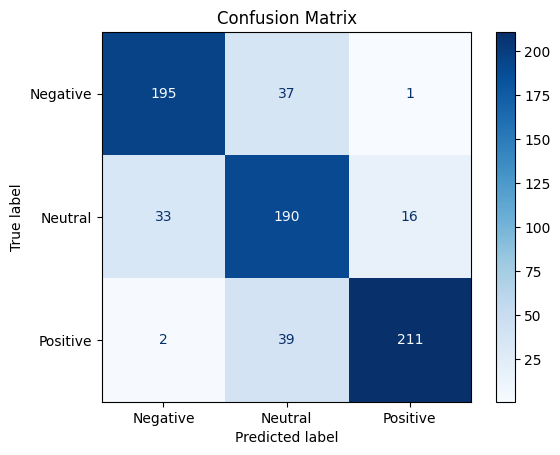

In [12]:
# Train using BERT base model
train_model("bert-base-uncased", "sentiment_bert")

Training model: roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-8-8ab4ca2ea504>:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.531131,0.794199,0.795548
2,No log,0.530058,0.803867,0.806362
3,0.491000,0.606744,0.824586,0.824382
4,0.491000,0.781880,0.816298,0.815653
5,0.491000,0.837793,0.825967,0.826923



Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84       233
     Neutral       0.73      0.77      0.75       239
    Positive       0.90      0.87      0.88       252

    accuracy                           0.83       724
   macro avg       0.83      0.83      0.83       724
weighted avg       0.83      0.83      0.83       724



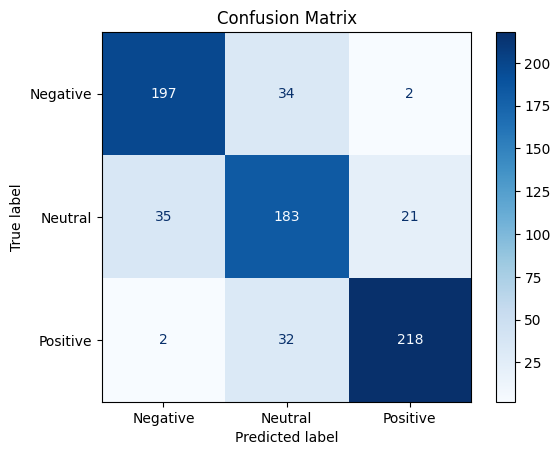

In [13]:
# Train using RoBERTa base model
train_model("roberta-base", "sentiment_roberta")

sentiment
Negative    1206
Neutral     1206
Positive    1206
Name: count, dtype: int64
percentage:
sentiment
Negative    33.333333
Neutral     33.333333
Positive    33.333333
Name: proportion, dtype: float64


<ipython-input-14-2874835e169f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_balanced, x='sentiment', palette='Set2')


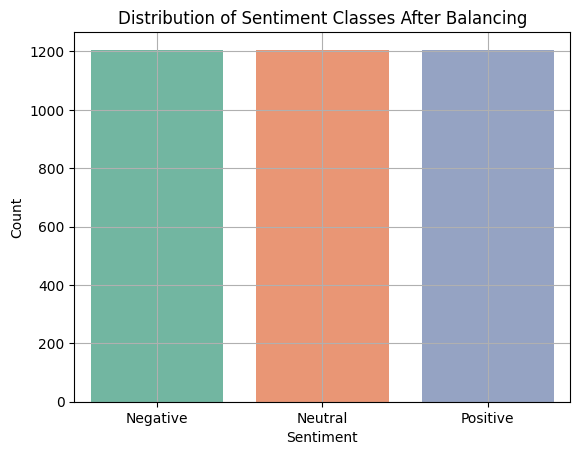

In [14]:
# Printing the count of reviews in each sentiment category after balancing
print(df_balanced['sentiment'].value_counts())

# Printing the percentage of reviews in each sentiment category after balancing
print("percentage:")
print(df_balanced['sentiment'].value_counts(normalize=True) * 100)

# Plotting the distribution of sentiment categories after balancing using Seaborn
sns.countplot(data=df_balanced, x='sentiment', palette='Set2')

# Adding a title to the plot
plt.title("Distribution of Sentiment Classes After Balancing")

# Labeling the x-axis with "Sentiment" to represent the sentiment categories
plt.xlabel("Sentiment")

# Labeling the y-axis with "Count" to represent the number of reviews in each sentiment category
plt.ylabel("Count")

# Enabling grid lines for the plot to make it easier to read
plt.grid(True)

# Displaying the plot
plt.show()


#Task 2. Product Category Clustering

In [15]:
# Extract Product Titles for Clustering
# We assume 'name' is the column with product titles.
product_titles = df[['name']].dropna().drop_duplicates().reset_index(drop=True)
print(f"Number of unique products: {len(product_titles)}")

Number of unique products: 65


In [16]:
# Generate Embeddings using Sentence-BERT
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')
product_titles['embedding'] = product_titles['name'].apply(lambda x: model_sbert.encode(x))

# Convert list of embeddings to numpy array
X_embeddings = np.vstack(product_titles['embedding'].values)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [17]:
# Cluster Products
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42) # KMeans clustering model with 5 clusters
product_titles['cluster'] = kmeans.fit_predict(X_embeddings) # Assign clusters to products

# Defining cluster labels for interpretation
cluster_labels = {
    0: "Accessories & Essentials",
    1: "Tablets & Streaming Devices",
    2: "Smart Home & Peripherals",
    3: "E-Book Readers",
    4: "Power & Charging"
}
product_titles['meta_category'] = product_titles['cluster'].map(cluster_labels)


In [18]:
#Interpret the Clusters
print("\n Sample Products per Cluster:")
for i in range(num_clusters):
    print(f"\n Cluster {i} — {cluster_labels[i]}")
    cluster_samples = product_titles[product_titles['cluster'] == i]['name'].sample(5, random_state=42)
    for prod in cluster_samples:
        print(f"  - {prod}")


 Sample Products per Cluster:

 Cluster 0 — Accessories & Essentials
  - AmazonBasics USB 3.0 Cable - A-Male to B-Male - 6 Feet (1.8 Meters)
  - AmazonBasics 16-Gauge Speaker Wire - 100 Feet
  - AmazonBasics Nylon CD/DVD Binder (400 Capacity)
  - AmazonBasics Single-Door Folding Metal Dog Crate - Large (42x28x30 Inches)
  - AmazonBasics External Hard Drive Case

 Cluster 1 — Tablets & Streaming Devices
  - Fire TV Stick Streaming Media Player Pair Kit
  - All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Marine Blue - with Special Offers
  - All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Blue
  - All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black
  - Fire Tablet with Alexa, 7 Display, 16 GB, Magenta - with Special Offers

 Cluster 2 — Smart Home & Peripherals
  - Amazon Echo (2nd Generation) Smart Assistant Oak Finish Priority Shipping
  - Amazon Echo ‚Äì White
  - Certified Refurbished Amazon Fire TV with Ale

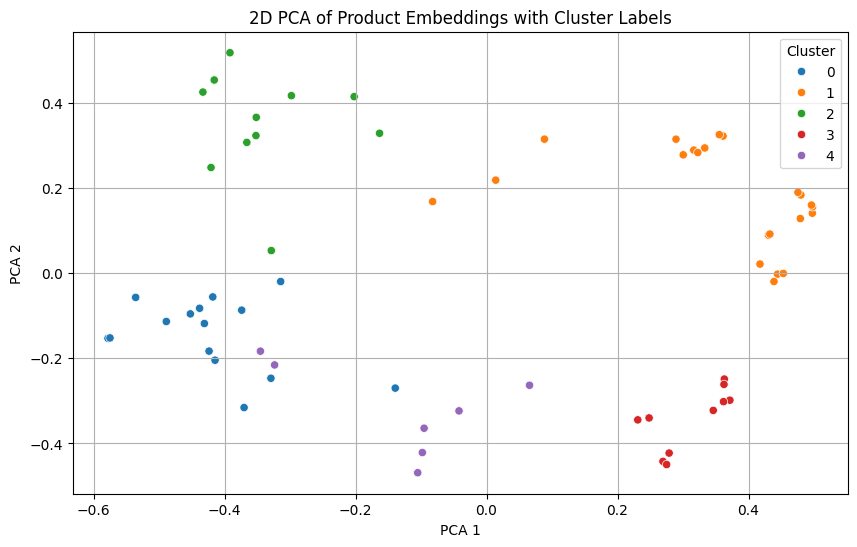

In [19]:
#2D Visualization ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # PCA to reduce embeddings to 2D space
X_2d = pca.fit_transform(X_embeddings) # Apply PCA to the embeddings

# Plotting the 2D PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=product_titles['cluster'], palette='tab10')
plt.title("2D PCA of Product Embeddings with Cluster Labels")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

#Task 3. Summarize reviews using generative AI

In [20]:
# Import the Hugging Face transformers pipeline for summarization
from transformers import pipeline

# Load the BART large CNN model for summarization
summarizer = pipeline("summarization", model="facebook/bart-large-cnn", device=0)

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [21]:
# Function to summarize reviews for a specific product
def summarize_reviews_for_product(df_reviews, product_name, summarizer):
    # Filter reviews for the given product name and drop any missing review texts
    product_reviews = df_reviews[df_reviews['name'] == product_name]['reviews.text'].dropna().tolist()

    # Combine the first 10 reviews into a single string for summarization
    reviews_text = " ".join(product_reviews[:10])
    # If there are no reviews, return a default message
    if not reviews_text.strip():
        return "No reviews available."
    # Generate the summary using the pipeline
    summary = summarizer(reviews_text, max_length=150, min_length=40, do_sample=False)[0]['summary_text']
    return summary


In [22]:
# Function to generate a summary for a product category (cluster)
def generate_category_summary(df, category_name, summarizer):
    print(f"\n## Category: {category_name}\n")

    # Filter products belonging to the specified category
    cat_df = df[df['meta_category'] == category_name]

    # Group by product name and aggregate average rating, review count, and texts
    grouped = cat_df.groupby('name').agg({
        'reviews.rating': ['mean', 'count'],
        'reviews.text': lambda x: list(x)
    }).reset_index()

    # Rename multi-level columns for simplicity
    grouped.columns = ['name', 'avg_rating', 'review_count', 'texts']

    # Only keep products that have 3 or more reviews
    grouped = grouped[grouped['review_count'] >= 3]

    # Select top 3 products with the highest average ratings
    top_3 = grouped.sort_values('avg_rating', ascending=False).head(3)

    # Select the product with the lowest average rating
    worst = grouped.sort_values('avg_rating').head(1)

    print("**Top 3 Products:**")
    for i, row in top_3.iterrows():
        # Summarize the reviews for each top product
        summary = summarize_reviews_for_product(cat_df, row['name'], summarizer)
        print(f"1. **{row['name']}** – Avg Rating: {row['avg_rating']:.2f}\n   > {summary}")

    print("\n** Worst Product:**")
    worst_row = worst.iloc[0]
    # Summarize the reviews for the lowest-rated product
    worst_summary = summarize_reviews_for_product(cat_df, worst_row['name'], summarizer)
    print(f"**{worst_row['name']}** – Avg Rating: {worst_row['avg_rating']:.2f}\n> {worst_summary}")


In [23]:
# Merge sentiment-labeled and clustered product data on 'name' (product title)
df_merged = df_balanced.merge(product_titles, on='name', how='inner')

# Get unique categories from the merged dataset
categories = df_merged['meta_category'].unique()

# Generate summaries for each product category
for category in categories:
    generate_category_summary(df_merged, category, summarizer)


## Category: Power & Charging

**Top 3 Products:**
1. **Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders** – Avg Rating: 3.60
   > I bought this because the package said it was a fast charger only to find it charges at normal speed. Kindle does not even provide a USB cable so that you can charge from your computer. The outlet plug is cheep plastic (hollow) and will probably break, no warranty.
1. **AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary** – Avg Rating: 2.78
   > The batteries are fine but the batteries themselves come pre-wrapped in groups of four! Every time you need more than four or if you're just going to split up some sets, you have to open a new group of four. They come wrapped in that horribly annoying cellophane like substance that is hard to remove. I probably wouldn't buy these again.
1. **AmazonBasics AAA Performance Alkaline Batteries (36 Count)** – Avg Rating: 2.72
   > The 48 packs

Your max_length is set to 150, but your input_length is only 139. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=69)


1. **Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers** – Avg Rating: 3.31
   > This device is good for entry level reader only in daylight. There is no backlight, so not good for reading in dark. Fits nicely in your hand and its touchable. increase the size of the fonts.

** Worst Product:**
**Kindle Oasis E-reader with Leather Charging Cover - Black, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers** – Avg Rating: 3.00
> This is not an upgrade by any means! My three year old kindle outperformed Oasis. Magnetic connector is poorly designed and grows weak. Two pieces to keep up with; unsnaps constantly.

## Category: Smart Home & Peripherals

**Top 3 Products:**
1. **Amazon Tap Smart Assistant Alexaenabled (black) Brand New** – Avg Rating: 3.34
   > The Tap has good sound, works excellent as a cooking timer. It's surprisingly sturdy but wish it was waterproof so I could take it with me while fishing. I would have rather had 

In [ ]:
# First run all previous code from your example, then add this Gradio section

!pip install gradio --quiet

import gradio as gr

# Load trained sentiment analysis model and tokenizer
sentiment_tokenizer = AutoTokenizer.from_pretrained("sentiment_roberta")
sentiment_model = AutoModelForSequenceClassification.from_pretrained("sentiment_roberta")

# Create sentiment analysis function
def analyze_sentiment(text):
    inputs = sentiment_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    outputs = sentiment_model(**inputs)
    probs = outputs.logits.softmax(dim=1)
    pred_label = probs.argmax().item()
    return id2label[pred_label]

# Prepare product dropdown options
product_options = product_titles['name'].unique().tolist()

# Create cluster visualization plot
def show_clusters():
    plt.figure(figsize=(10, 6))
    plot = sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=product_titles['cluster'], palette='Blues')
    plt.title("Product Clusters Visualization")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(title="Cluster")
    plt.grid(True)
    return plt.gcf()

# Custom CSS for styling
custom_css = """
body {background-color: #F0F8FF;}
h1 {color: #000000 !important;}
.gr-box {border-color: #4682B4 !important;}
.gr-button {background-color: #4682B4 !important; color: white !important;}
.gr-button:hover {background-color: #5F9EA0 !important;}
footer {visibility: hidden !important;}
"""

# Create Gradio interface
with gr.Blocks(css=custom_css, theme=gr.themes.Default(primary_hue="blue")) as demo:
    gr.Markdown("# Amazon Product Analysis Dashboard", elem_id="title")

    with gr.Tabs():
        with gr.TabItem("📝 Sentiment Analysis"):
            with gr.Row():
                with gr.Column():
                    input_text = gr.Textbox(label="Enter Product Review", lines=3,
                                         placeholder="Type your review here...")
                    analyze_btn = gr.Button("Analyze Sentiment")
                with gr.Column():
                    sentiment_output = gr.Label(label="Predicted Sentiment",
                                              elem_classes=["output-box"])

        with gr.TabItem("📦 Product Clusters"):
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Product Clusters Visualization")
                    cluster_plot = gr.Plot(label="Cluster Visualization")
                with gr.Column():
                    gr.Markdown("### Cluster Samples")
                    cluster_dropdown = gr.Dropdown(list(cluster_labels.values()),
                                                 label="Select Category")
                    cluster_samples = gr.Dataframe(headers=["Sample Products"],
                                                 elem_classes=["cluster-box"])

        with gr.TabItem("📊 Review Summarization"):
            with gr.Row():
                with gr.Column():
                    product_dropdown = gr.Dropdown(product_options,
                                                 label="Select Product")
                    summarize_btn = gr.Button("Generate Summary")
                with gr.Column():
                    summary_output = gr.Textbox(label="Review Summary", lines=5,
                                               elem_classes=["summary-box"])

    # Event handlers
    analyze_btn.click(
        fn=analyze_sentiment,
        inputs=input_text,
        outputs=sentiment_output
    )

    cluster_dropdown.change(
        fn=lambda x: product_titles[product_titles['meta_category'] == x].sample(5)[['name']].values.tolist(),
        inputs=cluster_dropdown,
        outputs=cluster_samples
    )

    summarize_btn.click(
        fn=lambda x: summarize_reviews_for_product(df, x, summarizer),
        inputs=product_dropdown,
        outputs=summary_output
    )

    demo.load(
        fn=show_clusters,
        outputs=cluster_plot
    )

# Launch the Gradio app
demo.launch(share=True, debug=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.8 MB/s eta 0:00:00
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://457393ab4d1e949d47.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Your max_length is set to 150, but your input_length is only 65. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=32)
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 2137, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 1663, in call_function
    prediction = await anyio.to_thread.run_sync(  #